# 03 — Preprocesamiento y Análisis Factorial (AFE, AFC, AFM)

**Freddie Mac Single-Family Loan-Level Dataset (SFLLD)**

Pipeline para preparar datos de mortgage-risk (Parquet) con RAPIDS y ejecutar análisis factorial sobre variables de **originación** (T=0).

---

## Estructura del notebook (alineada a Freddie Mac SFLLD)

| Parte | Contenido |
|-------|-----------|
| **I. Configuración** | Drive, RAPIDS, Cluster CUDA |
| **II. Carga de datos** | Parquet lazy con dask-cudf |
| **III. Poda** | Exclusión esparsas, constantes, fugas |
| **IV. Imputación** | Condicional (Co-Borrower, MI%, mediana) |
| **V. Agrupación geográfica** | Property_State → 9 divisiones censales |
| **VI. Transformación** | Winsorizing · PowerTransformer (Yeo-Johnson) |
| **VII. Muestreo y validación** | Cluster Sampling · Bondad de ajuste · SENECA |
| **VIII. AFE** | Análisis Factorial Exploratorio (minres) |
| **IX. AFC** | Análisis Factorial Confirmatorio (semopy) |
| **X. AFM** | Análisis Factorial Múltiple (prince.FAMD) |

## I. Configuración — Colab, RAPIDS y Cluster CUDA

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado en /content/drive')

Mounted at /content/drive
Drive montado en /content/drive


In [2]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
!pip install -q --extra-index-url=https://pypi.nvidia.com cudf-cu12 dask-cudf-cu12 dask-cuda rmm-cu12
!pip install -q factor_analyzer semopy prince scikit-learn matplotlib seaborn
print('\nRAPIDS + factor_analyzer + semopy + prince instalados.')

NVIDIA L4, 23034 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 195.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 11.1 MB/s eta 0:00:00

RAPIDS + factor_analyzer + semopy + prince instalados.


In [3]:
import os, gc
import cudf
import dask_cudf as dc
import pandas as pd
import numpy as np
from dask.distributed import Client
from dask_cuda import LocalCUDACluster
from dask.utils import parse_bytes

gpu_mem_query = !nvidia-smi --query-gpu=memory.total --format=csv,noheader,nounits
GPU_MEM_MB = int(gpu_mem_query[0].strip())
RMM_POOL   = f"{int(GPU_MEM_MB * 0.80)}MB"
DEV_LIMIT  = f"{int(GPU_MEM_MB * 0.70)}MB"

print(f'GPU VRAM: {GPU_MEM_MB} MB')
print(f'RMM pool: {RMM_POOL} | Spill threshold: {DEV_LIMIT}')

cluster = LocalCUDACluster(
    CUDA_VISIBLE_DEVICES='0',
    rmm_pool_size=parse_bytes(RMM_POOL),
    device_memory_limit=parse_bytes(DEV_LIMIT),
)
client = Client(cluster)
print(f'Dask dashboard: {client.dashboard_link}')
client

GPU VRAM: 23034 MB
RMM pool: 18427MB | Spill threshold: 16123MB


INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42883
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35919'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:46475 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:46475
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33238
INFO:distributed.scheduler:Receive client connection: Client-9dc959bf-15d6-11f1-9fd0-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33244


Dask dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: dask_cuda.LocalCUDACluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 1,Total memory: 52.96 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42883,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46475,Total threads: 1
Dashboard: http://127.0.0.1:34707/status,Memory: 52.96 GiB
Nanny: tcp://127.0.0.1:35919,


In [4]:
DRIVE_BASE     = '/content/drive/MyDrive'
PARQUET_PATH   = f'{DRIVE_BASE}/mortgage-risk/parquet/'
N_SAMPLE_LOANS = 10_000   # Conglomerados (préstamos) para Cluster Sampling
RANDOM_SEED    = 42

print(f'Parquet path: {PARQUET_PATH}')
print(f'Cluster Sampling: {N_SAMPLE_LOANS:,} Loan_Identifiers')

Parquet path: /content/drive/MyDrive/mortgage-risk/parquet/
Cluster Sampling: 10,000 Loan_Identifiers


---
## II. Carga de datos — Parquet lazy con dask-cudf

In [ ]:
ddf = dc.read_parquet(f'{PARQUET_PATH}*/**/*.parquet', split_row_groups=True)
print(f'Particiones Dask: {ddf.npartitions}')
print(f'Columnas: {list(ddf.columns)}')

Particiones Dask: 56
Columnas: ['Reference_Pool_ID', 'Loan_Identifier', 'Monthly_Reporting_Period', 'Channel', 'Seller_Name', 'Servicer_Name', 'Master_Servicer', 'Original_Interest_Rate', 'Current_Interest_Rate', 'Original_UPB', 'UPB_at_Issuance', 'Current_Actual_UPB', 'Original_Loan_Term', 'Origination_Date', 'First_Payment_Date', 'Loan_Age', 'Remaining_Months_to_Legal_Maturity', 'Remaining_Months_To_Maturity', 'Maturity_Date', 'Original_Loan_to_Value_Ratio_LTV', 'Original_Combined_Loan_to_Value_Ratio_CLTV', 'Number_of_Borrowers', 'Debt-To-Income_DTI', 'Borrower_Credit_Score_at_Origination', 'Co-Borrower_Credit_Score_at_Origination', 'First_Time_Home_Buyer_Indicator', 'Loan_Purpose', 'Property_Type', 'Number_of_Units', 'Occupancy_Status', 'Property_State', 'Metropolitan_Statistical_Area_MSA', 'Zip_Code_Short', 'Mortgage_Insurance_Percentage', 'Amortization_Type', 'Prepayment_Penalty_Indicator', 'Interest_Only_Loan_Indicator', 'Interest_Only_First_Principal_And_Interest_Payment_Date', 

---
## III. Poda — Exclusión de variables esparsas, constantes y fugas

In [6]:
# Columnas esparsas (>50% nulos) - ajustar nombres al esquema real
COLS_SPARSE = [
    'Foreclosure_Costs', 'Repurchase_Make_Whole_Proceeds', 'Principal_Forgiveness_Amount',
    'Foreclosure_Principal_Write-off_Amount', 'Property_Preservation_and_Repair_Costs',
    'Associated_Taxes_for_Holding_Property', 'Net_Sales_Proceeds'
]

# Constantes (cardinalidad 1)
COLS_CONSTANT = [
    'Amortization_Type', 'Prepayment_Penalty_Indicator', 'Special_Eligibility_Program',
    'High_Balance_Loan_Indicator', 'Payment_Deferral_Modification_Event_Indicator'
]

# Fugas / alta cardinalidad / target
COLS_LEAK = ['Zip_Code_Short', 'Current_Loan_Delinquency_Status']

all_exclude = set(COLS_SPARSE + COLS_CONSTANT + COLS_LEAK)
cols_present = [c for c in all_exclude if c in ddf.columns]
cols_to_drop = [c for c in cols_present]

if cols_to_drop:
    ddf = ddf.drop(columns=cols_to_drop)
    print(f'Excluidas {len(cols_to_drop)} columnas: {cols_to_drop}')
else:
    print('Ninguna columna de exclusión encontrada en el esquema (validar nombres).')

# Exclusión dinámica: esparsas >50% nulos (convertir a pandas: cuDF no soporta .index.tolist())
null_pct = (ddf.isnull().mean() * 100).compute().to_pandas()
sparse_dynamic = null_pct[null_pct > 50].index.tolist()
sparse_dynamic = [c for c in sparse_dynamic if c in ddf.columns]
if sparse_dynamic:
    ddf = ddf.drop(columns=sparse_dynamic)
    print(f'Excluidas esparsas dinámicas (>50% nulos): {sparse_dynamic}')

Excluidas 14 columnas: ['Net_Sales_Proceeds', 'Foreclosure_Costs', 'Amortization_Type', 'Principal_Forgiveness_Amount', 'Payment_Deferral_Modification_Event_Indicator', 'Property_Preservation_and_Repair_Costs', 'Special_Eligibility_Program', 'High_Balance_Loan_Indicator', 'Associated_Taxes_for_Holding_Property', 'Zip_Code_Short', 'Current_Loan_Delinquency_Status', 'Repurchase_Make_Whole_Proceeds', 'Foreclosure_Principal_Write-off_Amount', 'Prepayment_Penalty_Indicator']
Excluidas esparsas dinámicas (>50% nulos): ['Reference_Pool_ID', 'Monthly_Reporting_Period', 'Servicer_Name', 'Master_Servicer', 'UPB_at_Issuance', 'Origination_Date', 'First_Payment_Date', 'Maturity_Date', 'Co-Borrower_Credit_Score_at_Origination', 'Mortgage_Insurance_Percentage', 'Interest_Only_Loan_Indicator', 'Interest_Only_First_Principal_And_Interest_Payment_Date', 'Months_to_Amortization', 'Loan_Payment_History', 'Mortgage_Insurance_Cancellation_Indicator', 'Zero_Balance_Code', 'Zero_Balance_Effective_Date', 'UPB

---
## IV. Imputación condicional

In [7]:
CO_BORROWER_COL = 'Co-Borrower_Credit_Score_at_Origination'
BORROWER_COL   = 'Borrower_Credit_Score_at_Origination'
MI_COL         = 'Mortgage_Insurance_Percentage'
LTV_COL        = 'Original_Loan_to_Value_Ratio_LTV'

# 1. Co-Borrower: si nulo, usar Borrower
if CO_BORROWER_COL in ddf.columns and BORROWER_COL in ddf.columns:
    ddf[CO_BORROWER_COL] = ddf[CO_BORROWER_COL].fillna(ddf[BORROWER_COL])
    print('✓ Imputado Co-Borrower_Credit_Score con Borrower_Credit_Score')

# 2. Mortgage_Insurance_Percentage: 0 si LTV <= 80
if MI_COL in ddf.columns and LTV_COL in ddf.columns:
    # Usar map_partitions para evitar problemas de metadata
    def impute_mi(partition):
        partition = partition.copy()
        mask = partition[LTV_COL] <= 80
        partition.loc[mask, MI_COL] = 0.0
        partition[MI_COL] = partition[MI_COL].fillna(0.0)
        return partition

    ddf = ddf.map_partitions(impute_mi, meta=ddf._meta)
    print('✓ Imputado Mortgage_Insurance_Percentage (0 si LTV<=80)')

# 3. Mediana para resto de numéricas - SOLUCIÓN ROBUSTA
# Identificar columnas numéricas excluyendo las ya procesadas
exclude_cols = {CO_BORROWER_COL, MI_COL}
num_cols = [
    c for c in ddf.columns
    if c not in exclude_cols
    and str(ddf[c].dtype) in ('float32', 'float64', 'int32', 'int64', 'int8', 'float16')
]

print(f"Calculando medianas para {len(num_cols)} columnas numéricas...")

# Calcular medianas una por una para evitar problemas de metadata
fill_dict = {}
for col in num_cols:
    try:
        # Usar quantile con método específico y conversión explícita
        median_val = ddf[col].quantile(0.5).compute()

        # Manejar tanto scalares como Series de cuDF/pandas
        if hasattr(median_val, 'item'):
            val = median_val.item()  # Extraer valor escalar
        elif hasattr(median_val, 'iloc'):
            val = median_val.iloc[0] if len(median_val) > 0 else None
        else:
            val = float(median_val)

        if pd.notna(val):
            fill_dict[col] = val
            print(f"  {col}: {val:.4f}")
    except Exception as e:
        print(f"  ⚠️  Omitido {col}: {str(e)[:50]}")

# Aplicar imputación por lotes usando assign
if fill_dict:
    print(f"\nAplicando imputación en {len(fill_dict)} columnas...")

    # Método 1: Usar map_partitions (más seguro para cuDF)
    def fill_medians(partition, fill_dict=fill_dict):
        partition = partition.copy()
        for col, val in fill_dict.items():
            if col in partition.columns:
                partition[col] = partition[col].fillna(val)
        return partition

    ddf = ddf.map_partitions(fill_medians, meta=ddf._meta)

    print(f'✓ Imputación por mediana completada en {len(fill_dict)} columnas')
else:
    print("⚠️  No se encontraron medianas válidas para imputar")

Calculando medianas para 14 columnas numéricas...
  Original_Interest_Rate: 8.3000
  Current_Interest_Rate: 8.2500
  Original_UPB: 100000.0000
  Current_Actual_UPB: 72771.2734
  Original_Loan_Term: 360.0000
  Loan_Age: 21.0000
  Remaining_Months_to_Legal_Maturity: 341.0000
  Remaining_Months_To_Maturity: 337.0000
  Original_Loan_to_Value_Ratio_LTV: 80.0000
  Original_Combined_Loan_to_Value_Ratio_CLTV: 90.0000
  Number_of_Borrowers: 2.0000
  Debt-To-Income_DTI: 34.0000
  Borrower_Credit_Score_at_Origination: 720.0000
  Number_of_Units: 1.0000

Aplicando imputación en 14 columnas...
✓ Imputación por mediana completada en 14 columnas


---
## V. Agrupación geográfica — Property_State → 9 divisiones censales USA

In [8]:
# US Census Bureau: 9 divisiones (estado 2-letras -> división)
STATE_TO_DIVISION = {
    'CT': 'New_England', 'ME': 'New_England', 'MA': 'New_England', 'NH': 'New_England', 'RI': 'New_England', 'VT': 'New_England',
    'NJ': 'Middle_Atlantic', 'NY': 'Middle_Atlantic', 'PA': 'Middle_Atlantic',
    'IL': 'East_North_Central', 'IN': 'East_North_Central', 'MI': 'East_North_Central', 'OH': 'East_North_Central', 'WI': 'East_North_Central',
    'IA': 'West_North_Central', 'KS': 'West_North_Central', 'MN': 'West_North_Central', 'MO': 'West_North_Central', 'NE': 'West_North_Central', 'ND': 'West_North_Central', 'SD': 'West_North_Central',
    'DE': 'South_Atlantic', 'DC': 'South_Atlantic', 'FL': 'South_Atlantic', 'GA': 'South_Atlantic', 'MD': 'South_Atlantic', 'NC': 'South_Atlantic', 'SC': 'South_Atlantic', 'VA': 'South_Atlantic', 'WV': 'South_Atlantic',
    'AL': 'East_South_Central', 'KY': 'East_South_Central', 'MS': 'East_South_Central', 'TN': 'East_South_Central',
    'AR': 'West_South_Central', 'LA': 'West_South_Central', 'OK': 'West_South_Central', 'TX': 'West_South_Central',
    'AZ': 'Mountain', 'CO': 'Mountain', 'ID': 'Mountain', 'MT': 'Mountain', 'NV': 'Mountain', 'NM': 'Mountain', 'UT': 'Mountain', 'WY': 'Mountain',
    'AK': 'Pacific', 'CA': 'Pacific', 'HI': 'Pacific', 'OR': 'Pacific', 'WA': 'Pacific',
}

PROPERTY_STATE_COL = 'Property_State'
DIVISION_COL = 'Property_State_Division'

if PROPERTY_STATE_COL in ddf.columns:
    def _map_state_to_division(gdf):
        pdf = gdf.to_pandas()
        codes = pdf[PROPERTY_STATE_COL].astype(str).str.strip().str.upper().str[:2]
        pdf[DIVISION_COL] = codes.map(lambda x: STATE_TO_DIVISION.get(x, 'Unknown') if x and len(x)==2 else 'Unknown')
        pdf = pdf.drop(columns=[PROPERTY_STATE_COL])
        return cudf.from_pandas(pdf)
    ddf = ddf.map_partitions(_map_state_to_division)
    print('Property_State mapeado a 9 divisiones censales')
else:
    print('Property_State no encontrado en esquema')

Property_State mapeado a 9 divisiones censales


---
## VI. Transformación — Winsorizing y PowerTransformer (Yeo-Johnson)

In [9]:
# Límites winsorizing (p01-p99 del EDA)
WINSOR_LIMITS = {
    'Original_UPB': (25000, 248000),
    'Original_Interest_Rate': (6.25, 8.875),
    'Borrower_Credit_Score_at_Origination': (570, 804),
    'Original_Loan_to_Value_Ratio_LTV': (50, 100),
    'Debt-To-Income_DTI': (15, 55),
    'Original_Loan_Term': (180, 360),
}

for col, (lo, hi) in WINSOR_LIMITS.items():
    if col in ddf.columns:
        ddf[col] = ddf[col].clip(lower=lo, upper=hi)
print('Winsorizing aplicado')

Winsorizing aplicado


In [10]:
# PowerTransformer se aplica sobre la muestra tras .compute() (ver sección 8)
# Aquí definimos las columnas numéricas para el bloque continuo
NUM_BLOCK = [c for c in ddf.columns if c in [
    'Original_UPB', 'Original_Interest_Rate', 'Borrower_Credit_Score_at_Origination',
    'Original_Loan_to_Value_Ratio_LTV', 'Debt-To-Income_DTI', 'Original_Loan_Term',
    'Co-Borrower_Credit_Score_at_Origination', 'Mortgage_Insurance_Percentage'
]]
print(f'Bloque numérico para AF: {NUM_BLOCK}')

Bloque numérico para AF: ['Original_Interest_Rate', 'Original_UPB', 'Original_Loan_Term', 'Original_Loan_to_Value_Ratio_LTV', 'Debt-To-Income_DTI', 'Borrower_Credit_Score_at_Origination']


---
## VII. Muestreo y validación

### 7.1 Cluster Sampling (OOM-Safe)

En lugar de `sample(frac=...)` (que dispara shuffle y puede causar OOM), usamos **Cluster Sampling por Loan_Identifier**: extraemos N préstamos aleatorios y todas sus filas (historial completo). Esto preserva series temporales intactas y evita cruces masivos en GPU. *Justificación estadística*: cada préstamo es un conglomerado; al muestrear conglomerados obtenemos historiales completos, esencial para análisis longitudinal y AFM.

In [ ]:
ID_COL = 'Loan_Identifier'
N_PARTS_SCAN = min(30, ddf.npartitions)

# FASE 1: Seleccionar Loan_Identifiers de una partición
print('[FASE 1] Extrayendo pool de Loan_Identifiers...')
part0_cu = ddf.get_partition(0).compute()
pool_cu = part0_cu[ID_COL].dropna().unique()
n_pool = len(pool_cu)
print(f'  Pool: {n_pool:,} préstamos únicos en partición 0')

n_select = min(N_SAMPLE_LOANS, n_pool)
sampled_cu = pool_cu.sample(n=n_select, random_state=RANDOM_SEED)
sampled_set = set(sampled_cu.to_pandas().tolist())
print(f'  Conglomerados seleccionados: {len(sampled_set):,} Loan_Identifiers')

del pool_cu, sampled_cu, part0_cu
gc.collect()

# FASE 2: Extraer filas partición por partición (OOM-Safe)
print(f'\n[FASE 2] Escaneando {N_PARTS_SCAN} particiones...')
parts_cu = []
for i in range(N_PARTS_SCAN):
    try:
        part_cu = ddf.get_partition(i).compute()
        mask_cu = part_cu[ID_COL].isin(sampled_set)
        matched_cu = part_cu[mask_cu]
        if len(matched_cu) > 0:
            parts_cu.append(matched_cu)
        del part_cu, mask_cu, matched_cu
        gc.collect()
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{N_PARTS_SCAN} | {sum(len(p) for p in parts_cu):,} filas')
    except Exception as e:
        print(f'  [!] Partición {i}: {e}')
        gc.collect()

# Ensamblar en cuDF (GPU) y extraer snapshot estático (T=0)
if parts_cu:
    sample_cu = cudf.concat(parts_cu)
    del parts_cu
    gc.collect()
    sample_static_cu = sample_cu.drop_duplicates(subset=[ID_COL], keep='first')
    sample_pd = sample_cu.to_pandas()
    sample_static = sample_static_cu.to_pandas()
else:
    sample_cu = cudf.DataFrame()
    sample_static_cu = cudf.DataFrame()
    sample_pd = pd.DataFrame()
    sample_static = pd.DataFrame()

print(f'\nMuestreo por Conglomerados completado:')
print(f'  Filas totales: {len(sample_pd):,} | Snapshot estático (T=0): {len(sample_static):,} préstamos')

[FASE 1] Extrayendo pool de Loan_Identifiers...
  Pool: 14,603 préstamos únicos en partición 0
  Conglomerados seleccionados: 10,000 Loan_Identifiers

[FASE 2] Escaneando 30 particiones...
  10/30 | 404,982 filas
  20/30 | 405,464 filas
  30/30 | 405,464 filas

Muestreo por Conglomerados completado:
  Filas totales: 405,464 | Snapshot estático (T=0): 10,000 préstamos


### 7.2 Validación empírica (Población vs Muestra)

**Cuarteto de pruebas para muestreo irrefutable:**

1. **Bondad de Ajuste (Q1, Mediana, Q3)** — Las medianas de variables clave no deben variar.
2. **Divergencia Kullback-Leibler** — Valores < 0.05 confirman shape idéntico.
3. **Test Kolmogorov-Smirnov** — p-value > 0.05 confirma mismo universo.
4. **Test Chi-Cuadrado** — Valida proporciones categóricas.
5. **Matriz de Correlación** — Error máximo < 0.05 garantiza estructura multivariada para AFM.

In [ ]:
import numpy as np
from scipy import stats

print("Validando Muestra vs Población (Bondad de Ajuste)...")

id_col = 'Loan_Identifier'
rate_col = 'Original_Interest_Rate'
fico_col = 'Borrower_Credit_Score_at_Origination'
ltv_col = 'Original_Loan_to_Value_Ratio_LTV'
dti_col = 'Debt-To-Income_DTI'
upb_col = 'Original_UPB'

cols_to_check = [id_col, rate_col, fico_col, ltv_col, dti_col, upb_col]

if all(col in sample_pd.columns for col in cols_to_check):
    print("Calculando agregaciones de la Población (Dask Lazy Compute)...")
    pop_subset = ddf.partitions[0:min(5, ddf.npartitions)].compute()

    pop_unique = pop_subset.drop_duplicates(subset=[id_col])
    samp_unique = sample_pd.drop_duplicates(subset=[id_col])

    pop_rate = pop_unique[rate_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[rate_col].dropna()
    pop_fico = pop_unique[fico_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[fico_col].dropna()
    pop_ltv = pop_unique[ltv_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[ltv_col].dropna()
    pop_dti = pop_unique[dti_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[dti_col].dropna()
    pop_upb = pop_unique[upb_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[upb_col].dropna()

    samp_rate = samp_unique[rate_col].dropna()
    samp_fico = samp_unique[fico_col].dropna()
    samp_ltv = samp_unique[ltv_col].dropna()
    samp_dti = samp_unique[dti_col].dropna()
    samp_upb = samp_unique[upb_col].dropna()

    def compare_metrics(pop, samp, name):
        p_q1, p_med, p_q3 = pop.quantile([0.25, 0.50, 0.75])
        s_q1, s_med, s_q3 = samp.quantile([0.25, 0.50, 0.75])
        print(f"\n[{name}] -- Validación Q1, Q2(Mediana), Q3:")
        print(f"  Población: {p_q1:.2f} | {p_med:.2f} | {p_q3:.2f}")
        print(f"  Muestra:   {s_q1:.2f} | {s_med:.2f} | {s_q3:.2f}")
        print(f"  Diferencia Mediana: {abs(p_med - s_med):.3f}")

    compare_metrics(pop_rate, samp_rate, "Original Interest Rate")
    compare_metrics(pop_fico, samp_fico, "FICO Score")
    compare_metrics(pop_ltv, samp_ltv, "Original LTV (Colateral)")
    compare_metrics(pop_dti, samp_dti, "Original DTI (Capacidad)")
    compare_metrics(pop_upb, samp_upb, "Original UPB (Balance Inicial)")

    if len(pop_rate) > 0 and len(samp_rate) > 0:
        bins = np.histogram_bin_edges(np.concatenate([pop_rate.values, samp_rate.values]), bins=50)
        p_pop, _ = np.histogram(pop_rate, bins=bins, density=True)
        p_samp, _ = np.histogram(samp_rate, bins=bins, density=True)
        p_pop = np.where(p_pop == 0, 1e-10, p_pop)
        p_samp = np.where(p_samp == 0, 1e-10, p_samp)
        kl_div = stats.entropy(p_samp, p_pop)
        print(f"\nDivergencia de Kullback-Leibler (Tasa de Interés): {kl_div:.4f}")
        if kl_div < 0.05:
            print("\n COMPROBACIÓN COMPLETADA: La distribución es estadísticamente idéntica a la población (Baja Divergencia KL).")
        else:
            print("\n ALERTA: La divergencia es alta; la muestra podría no ser representativa.")

    print("\n" + "="*60)
    print("Test Kolmogorov-Smirnov (K-S) — Población vs Muestra")
    print("="*60)
    ks_pairs = [(pop_rate, samp_rate, "Original Interest Rate"), (pop_fico, samp_fico, "FICO Score"),
                (pop_ltv, samp_ltv, "Original LTV"), (pop_dti, samp_dti, "Original DTI"), (pop_upb, samp_upb, "Original UPB")]
    ks_ok = True
    for pop_s, samp_s, name in ks_pairs:
        if len(pop_s) > 0 and len(samp_s) > 0:
            stat, pval = stats.ks_2samp(pop_s.values, samp_s.values)
            ok = "OK" if pval > 0.05 else "ALERTA"
            print(f"  {name}: stat={stat:.4f}, p-value={pval:.4f} {ok}")
            if pval <= 0.05: ks_ok = False
    if ks_ok: print("  → No se rechaza H0: ambas distribuciones provienen del mismo universo.")
    else: print("  → ALERTA: Al menos una variable difiere significativamente (p ≤ 0.05).")

    print("\n" + "="*60)
    print("Test Chi-Cuadrado — Proporciones Categóricas")
    print("="*60)
    cat_cols_validar = [c for c in ['Loan_Purpose', 'Property_Type', 'Occupancy_Status'] if c in sample_pd.columns]
    pop_pd = pop_unique.to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique
    for cat_col in cat_cols_validar:
        pop_counts = pop_pd[cat_col].value_counts()
        samp_counts = samp_unique[cat_col].value_counts()
        all_cats = sorted(set(pop_counts.index.dropna()) | set(samp_counts.index.dropna()))
        all_cats = [c for c in all_cats if pd.notna(c)]
        if len(all_cats) < 2: continue
        obs_pop = pop_counts.reindex(all_cats, fill_value=0).values.astype(int)
        obs_samp = samp_counts.reindex(all_cats, fill_value=0).values.astype(int)
        obs_table = np.column_stack([obs_pop, obs_samp])
        try:
            chi2, p, dof, exp = stats.chi2_contingency(obs_table)
            ok = "OK" if p > 0.05 else "ALERTA"
            print(f"  {cat_col}: chi2={chi2:.2f}, p-value={p:.4f} {ok}")
        except Exception as e: print(f"  {cat_col}: (skip) {e}")

    print("\n" + "="*60)
    print("Estructura Multivariada — Error de Correlación")
    print("="*60)
    cols_corr = [rate_col, fico_col, ltv_col, dti_col, upb_col]
    pop_num = pop_pd[cols_corr].dropna()
    samp_num = samp_unique[cols_corr].dropna()
    if len(pop_num) > 10 and len(samp_num) > 10:
        corr_pop = pop_num.corr().fillna(0)
        corr_samp = samp_num.corr().fillna(0)
        corr_diff = (corr_pop - corr_samp).abs()
        np.fill_diagonal(corr_diff.values, 0)
        max_corr_error = corr_diff.max().max()
        print(f"  Error máximo de correlación: {max_corr_error:.4f}")
        if max_corr_error < 0.05: print("  EXCELENTE: Las relaciones y covarianzas se conservan intactas.")
        else: print("  ALERTA: La estructura de correlación difiere de la población.")

    del pop_subset, pop_unique, samp_unique, pop_pd
    gc.collect()
else:
    print("Columnas no encontradas. Verifica que los nombres coincidan exactamente con tu esquema.")

Validando Muestra vs Población (Bondad de Ajuste)...
Calculando agregaciones de la Población (Dask Lazy Compute)...

[Original Interest Rate] -- Validación Q1, Q2(Mediana), Q3:
  Población: 7.62 | 7.88 | 8.12
  Muestra:   7.62 | 7.88 | 8.12
  Diferencia Mediana: 0.000

[FICO Score] -- Validación Q1, Q2(Mediana), Q3:
  Población: 677.00 | 720.00 | 758.00
  Muestra:   678.00 | 721.00 | 759.00
  Diferencia Mediana: 1.000

[Original LTV (Colateral)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 70.00 | 80.00 | 90.00
  Muestra:   70.00 | 80.00 | 90.00
  Diferencia Mediana: 0.000

[Original DTI (Capacidad)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 26.00 | 34.00 | 41.00
  Muestra:   26.00 | 34.00 | 41.00
  Diferencia Mediana: 0.000

[Original UPB (Balance Inicial)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 77000.00 | 113000.00 | 157000.00
  Muestra:   76000.00 | 112000.00 | 157000.00
  Diferencia Mediana: 1000.000

Divergencia de Kullback-Leibler (Tasa de Interés): 0.0017

 COM

In [13]:
from sklearn.preprocessing import PowerTransformer

# PowerTransformer Yeo-Johnson sobre bloque numérico
num_cols_avail = [c for c in NUM_BLOCK if c in sample_static.columns]
X_num = sample_static[num_cols_avail].astype(float)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_num_trans = pt.fit_transform(X_num)
sample_static_num = pd.DataFrame(X_num_trans, columns=[f'{c}_yj' for c in num_cols_avail], index=sample_static.index)
print('PowerTransformer (Yeo-Johnson) aplicado al bloque numérico')

PowerTransformer (Yeo-Johnson) aplicado al bloque numérico


---
## VIII. AFE — Análisis Factorial Exploratorio

In [14]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# ==========================================
# PASO 1: PURGA DEL KMO (Identificar al culpable)
# ==========================================
X_afe = sample_static_num.dropna()
kmo_all, kmo_model = calculate_kmo(X_afe)

# Revisamos qué variable está dañando el KMO global
kmo_individual = pd.Series(kmo_all, index=X_afe.columns)
print("--- KMO Individual por Variable ---")
print(kmo_individual.sort_values())
print(f'\nKMO Global Original: {kmo_model:.4f}')

# ATENCIÓN: Mira la consola. Si ves variables con KMO < 0.50,
# debes eliminarlas de X_afe y volver a calcular el KMO.
# Ejemplo: X_afe = X_afe.drop(columns=['Variable_con_bajo_KMO'])


# ==========================================
# PASO 2, 3 Y 4: EXTRACCIÓN Y ROTACIÓN OBLICUA
# ==========================================
# Cambiamos a 'promax' (oblicua) porque las variables financieras están correlacionadas
n_factors = 3
fa = FactorAnalyzer(n_factors=n_factors, rotation='promax', method='minres')
fa.fit(X_afe)

print(f'\nVarianza explicada acumulada (3 factores): {fa.get_factor_variance()[2][2]:.2%}')


# ==========================================
# PASO 5: INTERPRETACIÓN (Cargas y Comunalidades)
# ==========================================
# 1. Comunalidades (Qué tanto explica el modelo cada variable)
comunalidades = pd.Series(fa.get_communalities(), index=X_afe.columns)
print("\n--- Comunalidades (Varianza explicada por variable) ---")
print(comunalidades.sort_values(ascending=False))

# 2. Matriz de Cargas Factoriales (Loadings)
loadings = pd.DataFrame(fa.loadings_, index=X_afe.columns, columns=['Factor 1', 'Factor 2', 'Factor 3'])

# Ocultamos valores bajos (< 0.3) para limpiar la lectura visual
loadings_limpio = loadings[abs(loadings) >= 0.3].fillna('')
print("\n--- Matriz de Cargas (Rotación Promax) ---")
print(loadings_limpio)

--- KMO Individual por Variable ---
Original_Interest_Rate_yj                  0.486987
Original_UPB_yj                            0.496128
Original_Loan_Term_yj                      0.560264
Borrower_Credit_Score_at_Origination_yj    0.581693
Original_Loan_to_Value_Ratio_LTV_yj        0.650751
Debt-To-Income_DTI_yj                      0.662758
dtype: float64

KMO Global Original: 0.5612

Varianza explicada acumulada (3 factores): 38.81%

--- Comunalidades (Varianza explicada por variable) ---
Original_Loan_Term_yj                      0.896930
Original_UPB_yj                            0.711684
Borrower_Credit_Score_at_Origination_yj    0.318533
Original_Interest_Rate_yj                  0.207033
Original_Loan_to_Value_Ratio_LTV_yj        0.131749
Debt-To-Income_DTI_yj                      0.062466
dtype: float64

--- Matriz de Cargas (Rotación Promax) ---
                                         Factor 1  Factor 2  Factor 3
Original_Interest_Rate_yj                0.365797          

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


--- FASE 1: MATRIZ DE CORRELACIONES ---


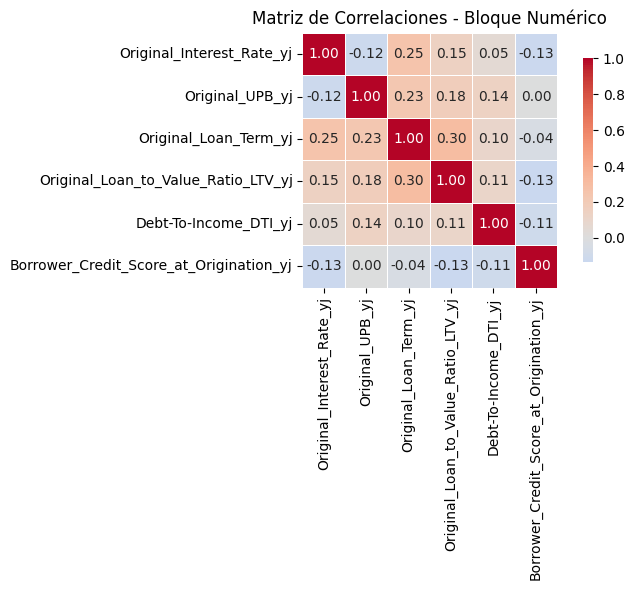


--- FASE 1.5: PRUEBAS DE ADECUACIÓN ---
KMO Global: 0.5612 (Debe ser > 0.60, ideal > 0.70)
Test de Bartlett: chi2 = 3475.07, p-value = 0.0000e+00 (Debe ser < 0.05)

[ALERTA] KMO Global bajo. Revisa estas variables problemáticas:
Original_Interest_Rate_yj    0.486987
Original_UPB_yj              0.496128
Original_Loan_Term_yj        0.560264
dtype: float64

--- FASE 2: TORNEO DE EXTRACCIÓN (3 Factores, Rotación Promax) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


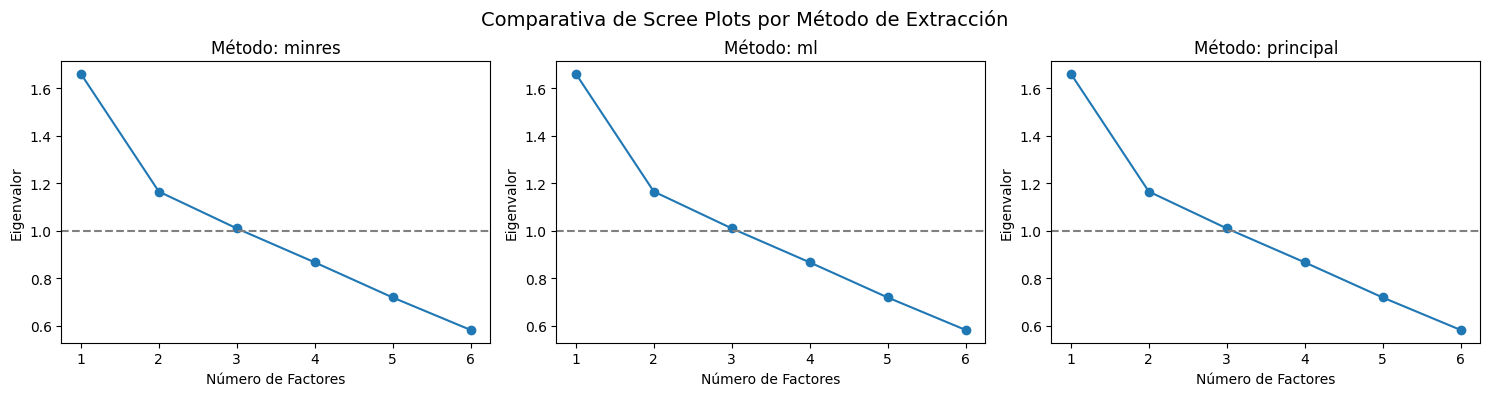


Resultados Finales:
   Método Var. Explicada Acum. Comunalidad Media  Estado
   minres               38.81%            0.3881 Exitoso
       ml               38.81%            0.3881 Exitoso
principal               64.46%            0.6446 Exitoso


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Asumiendo que X_afe es tu dataset numérico ya limpio y transformado
X_afe = sample_static_num.dropna()

# ==========================================
# FASE 1: MATRIZ DE CORRELACIONES
# ==========================================
print("--- FASE 1: MATRIZ DE CORRELACIONES ---")
corr_matrix = X_afe.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlaciones - Bloque Numérico")
plt.tight_layout()
plt.show()

# ==========================================
# FASE 1.5: PRUEBAS DE FACTORIZABILIDAD (KMO y Bartlett)
# ==========================================
print("\n--- FASE 1.5: PRUEBAS DE ADECUACIÓN ---")
kmo_all, kmo_model = calculate_kmo(X_afe)
chi2, pval = calculate_bartlett_sphericity(X_afe)

print(f"KMO Global: {kmo_model:.4f} (Debe ser > 0.60, ideal > 0.70)")
print(f"Test de Bartlett: chi2 = {chi2:.2f}, p-value = {pval:.4e} (Debe ser < 0.05)")

# Si el KMO es muy bajo, te muestro los peores para que sepas a quién eliminar
if kmo_model < 0.60:
    print("\n[ALERTA] KMO Global bajo. Revisa estas variables problemáticas:")
    kmo_individual = pd.Series(kmo_all, index=X_afe.columns).sort_values()
    print(kmo_individual.head(3))

# ==========================================
# FASE 2: COMPETENCIA DE MÉTODOS Y SCREE PLOTS
# ==========================================
print("\n--- FASE 2: TORNEO DE EXTRACCIÓN (3 Factores, Rotación Promax) ---")

metodos_a_probar = ['minres', 'ml', 'principal']
n_factors = 3
resultados = []

# Preparamos la figura para los 3 Scree Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparativa de Scree Plots por Método de Extracción', fontsize=14)

for i, metodo in enumerate(metodos_a_probar):
    try:
        fa = FactorAnalyzer(n_factors=n_factors, rotation='promax', method=metodo)
        fa.fit(X_afe)

        # Guardar métricas
        var_acumulada = fa.get_factor_variance()[2][2]
        comunalidad_media = np.mean(fa.get_communalities())

        resultados.append({
            'Método': metodo,
            'Var. Explicada Acum.': var_acumulada,
            'Comunalidad Media': comunalidad_media,
            'Estado': 'Exitoso'
        })

        # Generar Scree Plot para este método
        ev, v = fa.get_eigenvalues()
        axes[i].plot(range(1, len(ev)+1), ev, 'o-', color='#1f77b4')
        axes[i].axhline(1, color='gray', linestyle='--') # Línea del Criterio de Kaiser
        axes[i].set_title(f'Método: {metodo}')
        axes[i].set_xlabel('Número de Factores')
        axes[i].set_ylabel('Eigenvalor')

    except Exception as e:
        # Si Máxima Verosimilitud (ml) falla por matriz singular
        resultados.append({
            'Método': metodo,
            'Var. Explicada Acum.': 0,
            'Comunalidad Media': 0,
            'Estado': f'Error de convergencia'
        })
        axes[i].set_title(f'Método: {metodo} (FALLÓ)')
        axes[i].text(0.5, 0.5, 'Matriz Singular / No Converge',
                     ha='center', va='center', transform=axes[i].transAxes, color='red')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# Mostrar la tabla resumen
df_resultados = pd.DataFrame(resultados)
df_resultados['Var. Explicada Acum.'] = df_resultados['Var. Explicada Acum.'].apply(lambda x: f"{x:.2%}" if x > 0 else "N/A")
df_resultados['Comunalidad Media'] = df_resultados['Comunalidad Media'].apply(lambda x: f"{x:.4f}" if x > 0 else "N/A")

print("\nResultados Finales:")
print(df_resultados.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


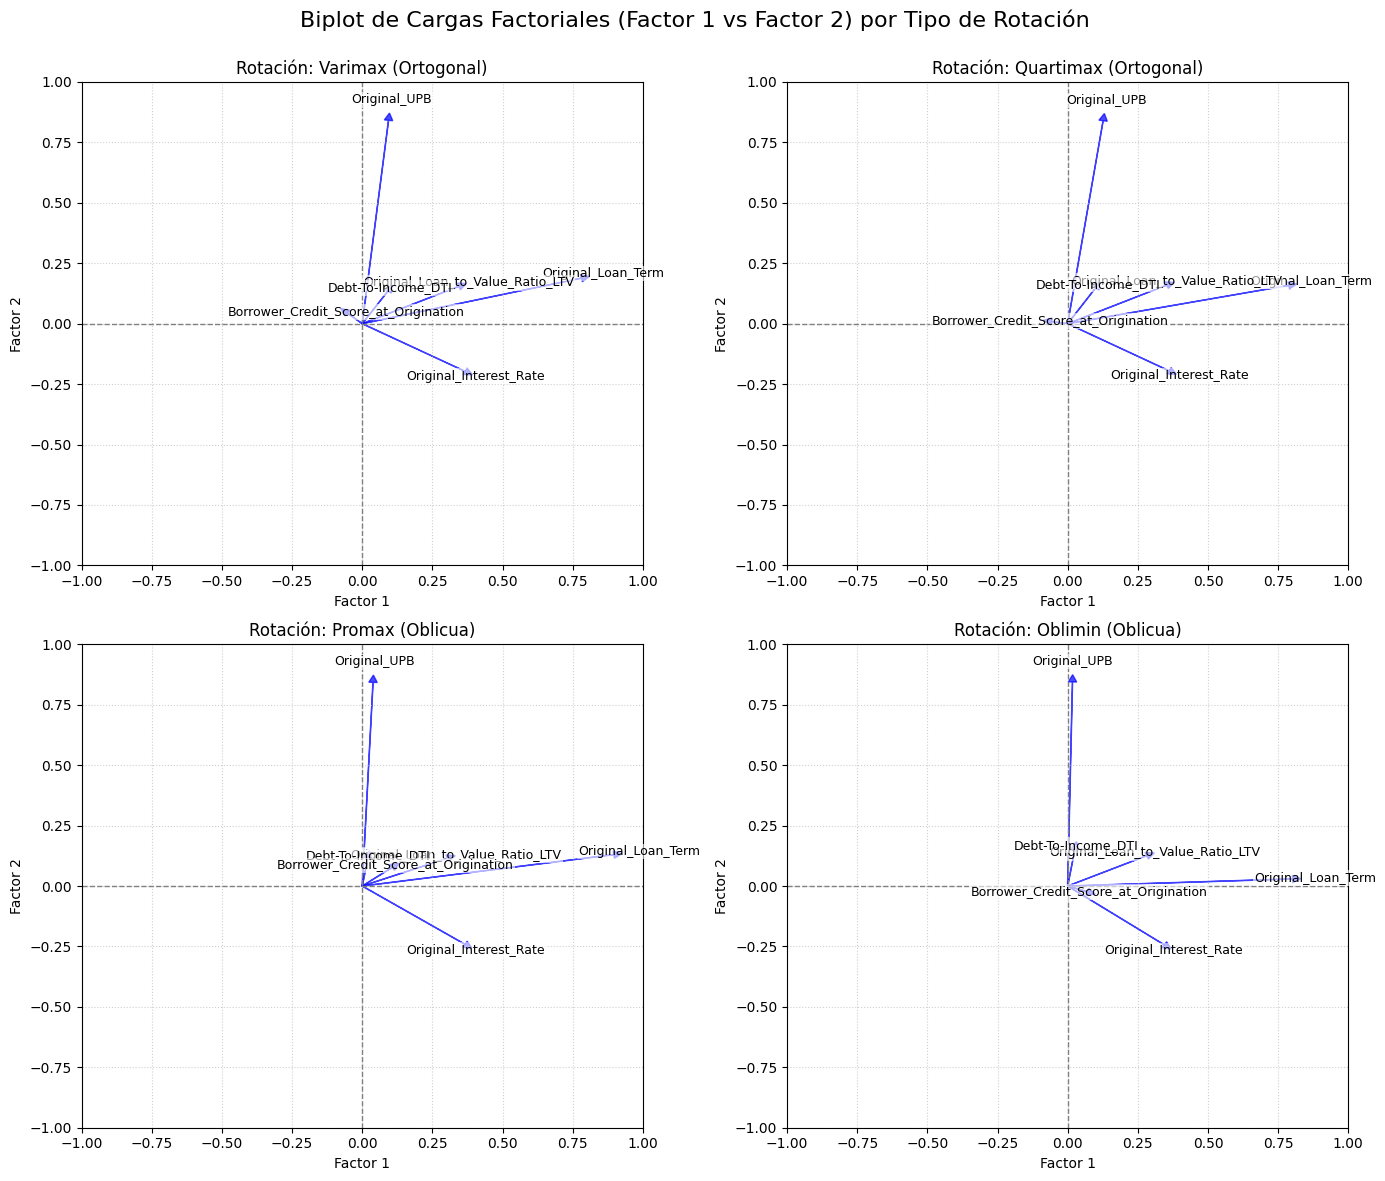


--- Matriz de Cargas Final (Rotación Oblimin) ---
                                               F1        F2        F3
Original_Interest_Rate_yj                0.344079                    
Original_UPB_yj                                    0.844309          
Original_Loan_Term_yj                     0.80126                    
Original_Loan_to_Value_Ratio_LTV_yj                                  
Debt-To-Income_DTI_yj                                                
Borrower_Credit_Score_at_Origination_yj                     -0.505236


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

# Asumiendo que X_afe es tu dataset numérico ya limpio y transformado
X_afe = sample_static_num.dropna()

# Definimos las rotaciones a comparar según la teoría
# Ortogonales (Ejes a 90° - Independientes): varimax, quartimax
# Oblicuas (Ejes < 90° - Correlacionados): promax, oblimin
rotaciones = ['varimax', 'quartimax', 'promax', 'oblimin']
n_factors = 3 # Según tu Scree Plot anterior

# Preparamos la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Biplot de Cargas Factoriales (Factor 1 vs Factor 2) por Tipo de Rotación', fontsize=16)
axes = axes.flatten()

for i, rot in enumerate(rotaciones):
    # Inicializar y ajustar el modelo
    fa = FactorAnalyzer(n_factors=n_factors, rotation=rot, method='minres')
    fa.fit(X_afe)

    # Extraer las cargas (loadings)
    loadings = fa.loadings_

    ax = axes[i]
    # Dibujar líneas de los ejes principales (0,0)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)

    # Graficar cada variable como un vector (flecha)
    for j, variable in enumerate(X_afe.columns):
        # Tomamos solo la carga en el Factor 1 (x) y Factor 2 (y)
        x_val = loadings[j, 0]
        y_val = loadings[j, 1]

        ax.arrow(0, 0, x_val, y_val, head_width=0.03, head_length=0.03, fc='blue', ec='blue', alpha=0.7)
        ax.text(x_val * 1.1, y_val * 1.1, variable.replace('_yj', ''),
                fontsize=9, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    # Configuración estética del gráfico
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Factor 1')
    ax.set_ylabel('Factor 2')

    # Títulos dinámicos según el tipo de rotación
    tipo = "Ortogonal" if rot in ['varimax', 'quartimax'] else "Oblicua"
    ax.set_title(f'Rotación: {rot.capitalize()} ({tipo})')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# ==========================================
# IMPRIMIR LA MATRIZ DE CARGAS DE LA MEJOR ROTACIÓN (Ej. Oblimin)
# ==========================================
fa_final = FactorAnalyzer(n_factors=n_factors, rotation='oblimin', method='minres')
fa_final.fit(X_afe)
loadings_df = pd.DataFrame(fa_final.loadings_, index=X_afe.columns, columns=['F1', 'F2', 'F3'])
print("\n--- Matriz de Cargas Final (Rotación Oblimin) ---")
print(loadings_df[abs(loadings_df) > 0.3].fillna('')) # Filtrar cargas < 0.3

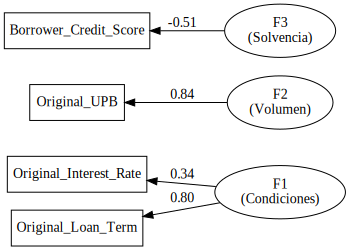

In [17]:
import graphviz
from IPython.display import display

# Crear el diagrama dirigido (Left to Right)
dot = graphviz.Digraph(comment='Análisis Factorial Exploratorio', format='png')
dot.attr(rankdir='RL') # Right to Left (para que los factores queden a la derecha como en tu imagen)

# 1. Crear los Nodos (Variables Observadas - Cuadrados/Cajas)
variables = [
    'Original_Interest_Rate',
    'Original_UPB',
    'Original_Loan_Term',
    'Borrower_Credit_Score'
]
for var in variables:
    dot.node(var, var, shape='box')

# 2. Crear los Nodos (Factores Latentes - Elipses)
dot.node('F1', 'F1\n(Condiciones)', shape='ellipse')
dot.node('F2', 'F2\n(Volumen)', shape='ellipse')
dot.node('F3', 'F3\n(Solvencia)', shape='ellipse')

# 3. Conectar Factores con Variables (Añadiendo las cargas en las flechas)
# Factor 1
dot.edge('F1', 'Original_Loan_Term', label='0.80')
dot.edge('F1', 'Original_Interest_Rate', label='0.34')

# Factor 2
dot.edge('F2', 'Original_UPB', label='0.84')

# Factor 3
dot.edge('F3', 'Borrower_Credit_Score', label='-0.51')

# Renderizar y mostrar en el notebook
display(dot)

In [18]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

X_afe = sample_static_num.dropna()
kmo_all, kmo_model = calculate_kmo(X_afe)
chi2, pval = calculate_bartlett_sphericity(X_afe)
print(f'KMO: {kmo_model:.4f} | Bartlett chi2={chi2:.2f}, p={pval:.2e}')

n_factors = 3
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='minres')
fa.fit(X_afe)
eigenvals = fa.get_eigenvalues()
print(f'\nEigenvalores: {eigenvals[0][:8]}')
print(f'Varianza explicada: {fa.get_factor_variance()}')

KMO: 0.5612 | Bartlett chi2=3475.07, p=0.00e+00

Eigenvalores: [1.65985468 1.16421706 1.00922006 0.86635471 0.71852927 0.58182422]
Varianza explicada: (array([0.88267994, 0.82642193, 0.39914247]), array([0.14711332, 0.13773699, 0.06652374]), array([0.14711332, 0.28485031, 0.35137406]))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


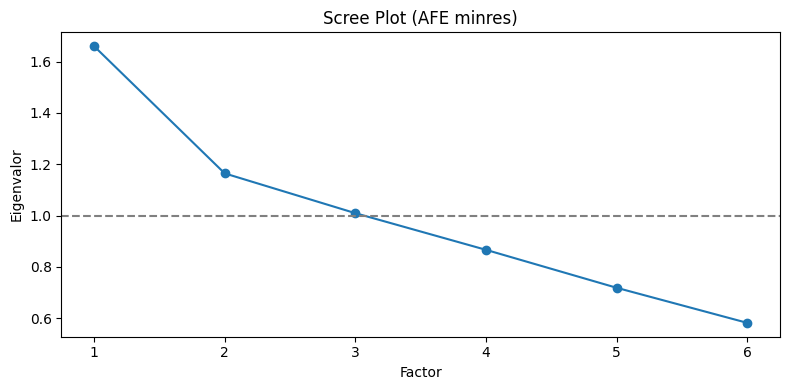

In [19]:
import matplotlib.pyplot as plt

ev = fa.get_eigenvalues()[0]
plt.figure(figsize=(8,4))
plt.plot(range(1, len(ev)+1), ev, 'o-')
plt.axhline(1, color='gray', linestyle='--')
plt.xlabel('Factor')
plt.ylabel('Eigenvalor')
plt.title('Scree Plot (AFE minres)')
plt.tight_layout()
plt.show()

---
## IX. AFC — Análisis Factorial Confirmatorio

In [20]:
import semopy

# semopy/lavaan interpreta el guion como operador menos: "Co-Borrower" -> "Co", "Debt-To-Income" -> "Debt"
# Renombrar ANTES de construir el modelo para evitar KeyError
cols_afc = [c for c in sample_static_num.columns if c.endswith('_yj')]
df_afc = sample_static_num[cols_afc].copy()
df_afc = df_afc.rename(columns=lambda x: x.replace('-', '_').replace(' ', '_'))
df_afc = df_afc.dropna()

# Solo columnas sin guiones (ya renombradas) para el model_desc
riesgo = [c for c in df_afc.columns if '-' not in c and ('Credit_Score' in c or 'DTI' in c or 'Debt' in c)]
terminos = [c for c in df_afc.columns if '-' not in c and ('UPB' in c or 'Interest_Rate' in c or 'LTV' in c or 'Loan_Term' in c)]
if len(riesgo) >= 2 and len(terminos) >= 2:
    cols_in_model = riesgo + terminos
    model_desc = f"Riesgo_Crediticio =~ {' + '.join(riesgo)}\n    Terminos_Prestamo =~ {' + '.join(terminos)}"
    model = semopy.Model(model_desc)
    model.fit(df_afc[cols_in_model])
    print(semopy.calc_stats(model))
else:
    print('Columnas insuficientes para AFC (se necesitan al menos 2 por factor). Disponibles:', list(df_afc.columns))

       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline       CFI  \
Value    8            15  968.529595           0.0    3476.400417  0.722503   

            GFI      AGFI       NFI       TLI    RMSEA        AIC         BIC  \
Value  0.721399  0.477623  0.721399  0.479692  0.10958  25.806294  119.540719   

         LogLik  
Value  0.096853  


---
## X. AFM — Análisis Factorial Múltiple (prince.FAMD)

In [21]:
import prince

# FAMD: Factor Analysis of Mixed Data (numérico + categórico crudo)
# Categóricas como strings; prince aplica MCA internamente. Sin One-Hot.
CAT_COLS_AFM = ['Channel', 'Loan_Purpose', 'Property_Type', 'Occupancy_Status', 'Property_State_Division']
cat_cols_avail = [c for c in CAT_COLS_AFM if c in sample_static.columns]
num_cols_afm = sample_static_num.columns.tolist()

X_mixed = pd.concat([sample_static_num, sample_static[cat_cols_avail].astype(str).fillna('Unknown')], axis=1).dropna(subset=num_cols_afm)

famd = prince.FAMD(n_components=3, n_iter=3, copy=True, random_state=RANDOM_SEED)
famd = famd.fit(X_mixed)
print(famd.eigenvalues_summary)

# Altair tiene límite 5000 filas; muestrear para el plot si hay muchas
MAX_PLOT_ROWS = 4500
X_plot = X_mixed.sample(n=min(MAX_PLOT_ROWS, len(X_mixed)), random_state=RANDOM_SEED) if len(X_mixed) > MAX_PLOT_ROWS else X_mixed
try:
    famd.plot(X_plot, x_component=0, y_component=1, show_row_labels=False)
except Exception as e:
    print(f'Plot omitido ({e}). Usar famd.row_coordinates(X_mixed) para coordenadas.')

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              3.372         6.30%                      6.30%
1              3.085         5.77%                     12.07%
2              3.033         5.67%                     17.74%
